##Impotación de librerias

In [ ]:
# Librerías para manipulación y visualización de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para división de datos y búsqueda de hiperparámetros
from sklearn.model_selection import train_test_split, GridSearchCV

# Librerías para modelos de regresión
from sklearn.linear_model import LinearRegression, Lasso

# Librerías para construcción de pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Librerías para preprocesamiento de datos
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PolynomialFeatures
)

# Librerías para métricas de evaluación
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### Se carga el dataframe

In [ ]:
# Importar el archivo
from google.colab import files
file = files.upload()

Saving Datos_Etapa-1.csv to Datos_Etapa-1 (1).csv


In [ ]:
ruta = 'Datos_Etapa-1.csv'
data = pd.read_csv(ruta, sep=',')

## 1. Exploración y perfilamiento de datos

#### Correlación y Colinealidad

#####Se calcula la matriz de correlación de Pearson entre las variables numéricas con el objetivo de identificar posibles problemas de colinealidad o correlación:

In [ ]:
data.corr(method="pearson", numeric_only=True)

,weekday,temp,atemp,hum,windspeed,cnt
weekday,1.000000,-0.001795,-0.008821,-0.037158,0.011502,0.026900
temp,-0.001795,1.000000,0.987672,-0.069881,-0.023125,0.404772
atemp,-0.008821,0.987672,1.000000,-0.051918,-0.062336,0.400929
hum,-0.037158,-0.069881,-0.051918,1.000000,-0.290105,-0.322911
windspeed,0.011502,-0.023125,-0.062336,-0.290105,1.000000,0.093234
cnt,0.026900,0.404772,0.400929,-0.322911,0.093234,1.000000


##### Se observa una alta correlación entre las variables "temp" y "atemp" (0.988), por lo que una de ellas será eliminada durante la fase de modelado para evitar problemas de colinealidad.
De igual manera, las variables "weekday" y "windspeed" presentan correlaciones casi nulas con respecto a la variable dependiente "cnt" (0.027 y 0.093 respectivamente), por lo que muy probablemente no sean relevantes en el modelo. Para verificar esto, se eliminará una de estas variables y se dejará la otra, permitiendo evaluar al final del análisis si efectivamente aporta o no al poder predictivo de los modelos.

Estas relaciones se observan con mayor claridad en el siguiente mapa de calor:

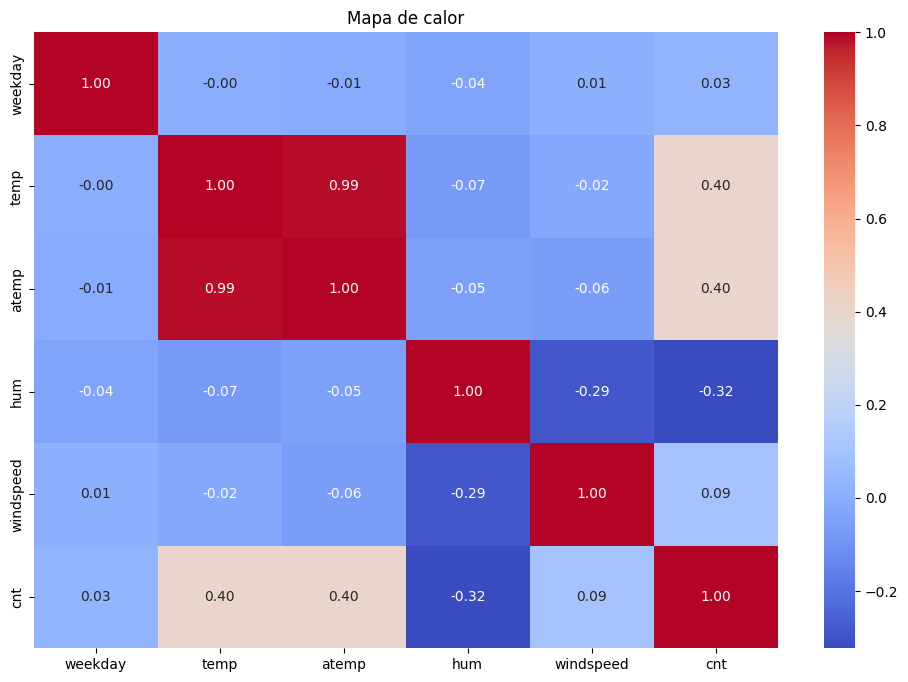

In [ ]:
# Generar mapa de calor con la matriz de correlación
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Mapa de calor")
plt.show()

#### Validación con el diccionario y lógica del problema

In [ ]:
#Dimensiones del df
data.shape

(17379, 9)

In [ ]:
#Primeras filas del df
data.head()

,season,weekday,weathersit,temp,atemp,hum,windspeed,cnt,time_of_day
0,Winter,6,Clear,3.28,3.0014,0.81,0.0,16,Night
1,Winter,6,Clear,2.34,1.9982,0.80,0.0,40,Night
2,Winter,6,Clear,2.34,1.9982,0.80,0.0,32,Night
3,Winter,6,Clear,3.28,3.0014,0.75,0.0,13,Night
4,Winter,6,Clear,3.28,3.0014,0.75,0.0,1,Night


In [ ]:
#Resumen estadistíco
data.describe()

,weekday,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,3.003683,15.358397,15.401157,0.627229,12.736540,189.463088
std,2.005771,9.050138,11.342114,0.192930,8.196795,181.387599
min,0.000000,-7.060000,-16.000000,0.000000,0.000000,1.000000
25%,1.000000,7.980000,5.997800,0.480000,7.001500,40.000000
50%,3.000000,15.500000,15.996800,0.630000,12.998000,142.000000
75%,5.000000,23.020000,24.999200,0.780000,16.997900,281.000000
max,6.000000,39.000000,50.000000,1.000000,56.996900,977.000000


##### Se puede observar cómo el "weekday" inicia en "0" y finaliza en "6", lo cual difiere del diccionario. En este último también se aprecia cómo los días de la semana tienen un valor jerárquico, algo que en la práctica no es correcto, por lo que también deberá corregirse.

#### Tipos de variable

##### Aquí se ve cómo hay variables categóricas, por lo que deberán convertirse a numéricas al construir el pipeline. Para ello, se utilizará el one-hot encoder.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       17379 non-null  object 
 1   weekday      17379 non-null  int64  
 2   weathersit   17379 non-null  object 
 3   temp         17379 non-null  float64
 4   atemp        17379 non-null  float64
 5   hum          17379 non-null  float64
 6   windspeed    17379 non-null  float64
 7   cnt          17379 non-null  int64  
 8   time_of_day  17379 non-null  object 
dtypes: float64(4), int64(2), object(3)
memory usage: 1.2+ MB


#### Datos ausentes

In [ ]:
#Visualizar si hay datos ausentes en el df
data.isna()

,season,weekday,weathersit,temp,atemp,hum,windspeed,cnt,time_of_day
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
17374,False,False,False,False,False,False,False,False,False
17375,False,False,False,False,False,False,False,False,False
17376,False,False,False,False,False,False,False,False,False
17377,False,False,False,False,False,False,False,False,False


In [ ]:
#Ver cuantos datos ausentes hay, apreciamos que no hay
data.isna().sum()

,0
season,0
weekday,0
weathersit,0
temp,0
atemp,0
hum,0
windspeed,0
cnt,0
time_of_day,0


#### Duplicados

In [ ]:
#Se busca si hay datos duplicados, se puede notar que hay 42
data.duplicated(), data.duplicated().sum()

(0        False
 1        False
 2        False
 3        False
 4        False
          ...  
 17374    False
 17375    False
 17376    False
 17377    False
 17378    False
 Length: 17379, dtype: bool,
 np.int64(42))

## 2. Limpieza y preparación de datos

#### Eliminación de duplicados

In [ ]:
#Se crea un nuevo df, eliminando los duplicados
df = data.drop_duplicates()

In [ ]:
#Comprobar
df.shape, df.duplicated().sum()

((17337, 9), np.int64(0))

#### Selección de variables

##### Con base en el análisis anterior, se excluyen dos variables del modelo:
1. Variable "atemp": Se descarta debido a su alta colinealidad con "temp" (correlación de 0.99). Se opta por esta última porque representa una medida objetiva y universal de temperatura, a diferencia de "atemp" (Sensación de temperatura), que refleja una percepción subjetiva que puede variar entre individuos.

2. Variable "weekday": Se elimina por las siguientes razones:

*   Correlación casi nula: Presenta una correlación de 0.03 con la variable objetivo, tres veces menor que la de "windspeed" (0.09), lo cual indica que no aporta información predictiva relevante.

* Naturaleza categórica sin orden: Aunque está codificada numéricamente (0-6), los días de la semana no tienen un orden jerárquico real, por lo que esta codificación es arbitraria.

* Costo computacional: Al ser categórica, requeriría aplicar One-Hot Encoding, lo que generaría 6 columnas dummy adicionales. Esto aumentaría considerablemente la complejidad del modelo sin ofrecer beneficio predictivo alguno, contradiciendo el principio de parsimonia.

Por tanto, se mantienen las variables numéricas: temp, hum y windspeed; y las categóricas: season, weathersit y time_of_day para la construcción de los modelos.

##3. Regresión Polinomial

#### Selección de Variables

Se definen las variables predictoras separándolas en:
- Variables categóricas (requieren One-Hot Encoding).
- Variables numéricas (requieren escalado).

La variable objetivo será "cnt", que representa el número de alquileres.

In [ ]:
# Variables categóricas que serán codificadas con One-Hot Encoding
cat_var = ['season', 'weathersit', 'time_of_day']

# Variables numéricas que serán escaladas
num_var = ['temp', 'hum', 'windspeed']

# Variables predictoras
X = df[cat_var + num_var]

# Variable objetivo
y = df['cnt']

#### División de los datos

Se divide el dataset en:
- 80% entrenamiento
- 20% prueba

Esto permite evaluar la capacidad de generalización del modelo.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=77
)

#### Construcción del Pipeline

Se construye un Pipeline que incluye:

1. Preprocesamiento:
   * One-Hot Encoding para variables categóricas.
   * Escalado para variables numéricas.
   
2. Generación de características polinomiales:
   * Permite modelar relaciones no lineales.

3. Modelo:
   * Regresión Lineal.

In [ ]:
pipeline_poly = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first'), cat_var),
        ('num', StandardScaler(), num_var)
    ])),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('model', LinearRegression())
])

#### Optimización de Hiperparámetros

Se utiliza GridSearchCV para evaluar diferentes combinaciones de:

* Tipo de escalador:
  * StandardScaler
  * MinMaxScaler
  * RobustScaler

* Grado polinomial:
  * 2
  * 3

La métrica utilizada es RMSE (neg_root_mean_squared_error).

In [ ]:
param_grid_poly = {
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'poly__degree': [2, 3]
}

grid_search_poly = GridSearchCV(
    pipeline_poly,
    param_grid_poly,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

grid_search_poly.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['season',
                                                                          'weathersit',
                                                                          'time_of_day']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['temp',
                                                                          'hum',
                                                                          'windspeed'])])),
                                       ('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('model', LinearRegression())]),
             n_jobs=-1,
             param_grid={'poly__degree': [2, 3],
                         'preprocessor__num': [StandardScaler(), MinMaxScaler(),
                                               RobustScaler()]},
             scoring='neg_root_mean_squared_error', verbose=2)

#### Evaluación del Mejor Modelo

Se evalúa el mejor modelo encontrado por GridSearchCV en el conjunto de prueba.

In [ ]:
y_pred_test_poly = grid_search_poly.predict(X_test)
rmse_test_poly = np.sqrt(mean_squared_error(y_test, y_pred_test_poly))

####  Resultados del Mejor Modelo

Se presentan:

- Los mejores hiperparámetros encontrados.
- El RMSE obtenido en validación cruzada.
- El RMSE en el conjunto de prueba.
- La comparación entre todas las combinaciones evaluadas.

In [ ]:
# Predicciones en el conjunto de prueba
y_pred_test_poly = grid_search_poly.predict(X_test)

# Cálculo del RMSE en test
rmse_test_poly = np.sqrt(mean_squared_error(y_test, y_pred_test_poly))

# DataFrame con los resultados principales
mejor_modelo_poly = pd.DataFrame({
    'Métrica': [
        'Scaler seleccionado',
        'Grado Polinomial',
        'RMSE (Validación Cruzada)',
        'RMSE (Test)'
    ],
    'Valor': [
        str(grid_search_poly.best_params_['preprocessor__num']),
        grid_search_poly.best_params_['poly__degree'],
        round(-grid_search_poly.best_score_, 4),
        round(rmse_test_poly, 4)
    ]
})

display(mejor_modelo_poly)

,Métrica,Valor
0,Scaler seleccionado,StandardScaler()
1,Grado Polinomial,3
2,RMSE (Validación Cruzada),130.216
3,RMSE (Test),133.5015


In [ ]:
# Convertir resultados completos de GridSearchCV en DataFrame
resultados_df_poly = pd.DataFrame(grid_search_poly.cv_results_)

# Seleccionar columnas relevantes
tabla_resultados_poly = resultados_df_poly[
    ['param_preprocessor__num', 'param_poly__degree', 'mean_test_score']
].copy()

# Convertir score negativo a RMSE positivo
tabla_resultados_poly['RMSE'] = -tabla_resultados_poly['mean_test_score']

# Renombrar columnas para mayor claridad
tabla_resultados_poly = tabla_resultados_poly.rename(columns={
    'param_preprocessor__num': 'Scaler',
    'param_poly__degree': 'Grado'
})

# Ordenar por mejor desempeño (menor RMSE)
tabla_final_poly = tabla_resultados_poly[['Scaler', 'Grado', 'RMSE']]\
    .sort_values('RMSE', ascending=True)\
    .reset_index(drop=True)

display(tabla_final_poly)

,Scaler,Grado,RMSE
0,StandardScaler(),3,130.216040
1,RobustScaler(),3,130.216102
2,MinMaxScaler(),3,130.216398
3,RobustScaler(),2,132.292251
4,StandardScaler(),2,132.292449
5,MinMaxScaler(),2,132.293766


## 4. Regresión Lasso

#### Construcción del Pipeline

El Pipeline incluye:

1. Preprocesamiento:
   * One-Hot Encoding para variables categóricas.
   * Escalado para variables numéricas.
   
2. Modelo:
   * Regresión Lasso.
   * Se ajustará el parámetro alpha (nivel de regularización).

In [ ]:
pipeline_lasso = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first'), cat_var),
        ('num', StandardScaler(), num_var)
    ])),
    ('model', Lasso(random_state=77, max_iter=10000))
])

#### Optimización de Hiperparámetros

Se evaluarán:

* 3 tipos de escaladores:
  * StandardScaler
  * MinMaxScaler
  * RobustScaler

* 5 valores de alpha (parámetro de regularización):
  * 1, 2, 3, 4, 5

Total combinaciones evaluadas:
3 * 5 = 15 modelos.

In [ ]:
param_grid_lasso = {
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'model__alpha': [1, 2, 3, 4, 5]
}

#### Se utiliza GridSearchCV con validación cruzada de 5 folds.
La métrica de evaluación es RMSE (neg_root_mean_squared_error).

In [ ]:
grid_search_lasso = GridSearchCV(
    pipeline_lasso,
    param_grid_lasso,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

print("Entrenando GridSearchCV para Regresión Lasso...")
grid_search_lasso.fit(X_train, y_train)

Entrenando GridSearchCV para Regresión Lasso...
Fitting 5 folds for each of 15 candidates, totalling 75 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['season',
                                                                          'weathersit',
                                                                          'time_of_day']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['temp',
                                                                          'hum',
                                                                          'windspeed'])])),
                                       ('model',
                                        Lasso(max_iter=10000,
                                              random_state=77))]),
             n_jobs=-1,
             param_grid={'model__alpha': [1, 2, 3, 4, 5],
                         'preprocessor__num': [StandardScaler(), MinMaxScaler(),
                                               RobustScaler()]},
             scoring='neg_root_mean_squared_error', verbose=2)

#### Evaluación del Mejor Modelo Lasso

Se obtienen:

* Mejores hiperparámetros
* RMSE en validación cruzada
* RMSE en conjunto de prueba

In [ ]:
# Predicciones en test
y_pred_test_lasso = grid_search_lasso.predict(X_test)

# RMSE en test
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

# Tabla resumen
mejor_modelo_lasso = pd.DataFrame({
    'Métrica': [
        'Scaler seleccionado',
        'Alpha óptimo',
        'RMSE (Validación Cruzada)',
        'RMSE (Test)'
    ],
    'Valor': [
        str(grid_search_lasso.best_params_['preprocessor__num']),
        grid_search_lasso.best_params_['model__alpha'],
        round(-grid_search_lasso.best_score_, 4),
        round(rmse_test_lasso, 4)
    ]
})

display(mejor_modelo_lasso)

,Métrica,Valor
0,Scaler seleccionado,StandardScaler()
1,Alpha óptimo,1
2,RMSE (Validación Cruzada),136.5947
3,RMSE (Test),140.1261


#### Tabla Completa de Resultados

In [ ]:
# Convertir los resultados completos de la validación cruzada en un DataFrame
resultados_df_lasso = pd.DataFrame(grid_search_lasso.cv_results_)

# Seleccionar únicamente las columnas relevantes para el análisis
tabla_resultados_lasso = resultados_df_lasso[
    ['param_preprocessor__num', 'param_model__alpha', 'mean_test_score']
].copy()

# Convertir el score negativo a RMSE positivo
# Se multiplica por -1 porque se utilizó 'neg_root_mean_squared_error' como métrica
tabla_resultados_lasso['RMSE'] = -tabla_resultados_lasso['mean_test_score']

# Renombrar las columnas para que sean más claras y fáciles de interpretar
tabla_resultados_lasso = tabla_resultados_lasso.rename(columns={
    'param_preprocessor__num': 'Scaler',
    'param_model__alpha': 'Alpha'
})

# Seleccionar las columnas finales, ordenar de menor a mayor RMSE
# (menor error = mejor desempeño) y reiniciar el índice
tabla_final_lasso = tabla_resultados_lasso[['Scaler', 'Alpha', 'RMSE']]\
    .sort_values('RMSE', ascending=True)\
    .reset_index(drop=True)

# Mostrar la tabla final con todas las combinaciones evaluadas
display(tabla_final_lasso)

,Scaler,Alpha,RMSE
0,StandardScaler(),1,136.594657
1,RobustScaler(),1,136.619089
2,MinMaxScaler(),1,136.927559
3,StandardScaler(),2,137.509141
4,RobustScaler(),2,137.517508
5,MinMaxScaler(),2,138.208316
6,StandardScaler(),3,138.393996
7,RobustScaler(),3,138.451407
8,MinMaxScaler(),3,139.262605
9,StandardScaler(),4,139.290885


## 5 Comparación Final de Modelos

#### Cálculo de Métricas

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predicciones del mejor modelo Polinomial
y_pred_poly = grid_search_poly.predict(X_test)

# Predicciones del mejor modelo Lasso
y_pred_lasso = grid_search_lasso.predict(X_test)

# Métricas Regresión Polinomial
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae_poly = mean_absolute_error(y_test, y_pred_poly)

# Métricas Regresión Lasso
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

#### Tabla Comparativa

In [ ]:
# Se incluyen los dos modelos evaluados: Regresión Polinomial y Regresión Lasso
tabla_comparativa = pd.DataFrame({
    'Modelo': ['Regresión Polinomial', 'Regresión Lasso'],
    'R²': [round(r2_poly, 4), round(r2_lasso, 4)],
    'RMSE': [round(rmse_poly, 4), round(rmse_lasso, 4)],
    'MAE': [round(mae_poly, 4), round(mae_lasso, 4)]
})

print("\nTABLA COMPARATIVA DE MODELOS:")
display(tabla_comparativa)


TABLA COMPARATIVA DE MODELOS:


,Modelo,R²,RMSE,MAE
0,Regresión Polinomial,0.4698,133.5015,96.3280
1,Regresión Lasso,0.4159,140.1261,103.7224


#### Identificación del Mejor Modelo

In [ ]:
# Modelo con menor RMSE
mejor_idx = tabla_comparativa['RMSE'].idxmin()
mejor_modelo = tabla_comparativa.loc[mejor_idx, 'Modelo']

print(f"\nMejor modelo según RMSE: {mejor_modelo}")


Mejor modelo según RMSE: Regresión Polinomial


## 6. Interpretación del Modelo Lasso

#### Obtener el mejor modelo entrenado

In [ ]:
# Mejor modelo Lasso encontrado por GridSearch
mejor_lasso = grid_search_lasso.best_estimator_

#### Obtener nombres de las variables después del preprocesamiento

In [ ]:
# Obtener el preprocesador
preprocessor = mejor_lasso.named_steps['preprocessor']

# Nombres de variables categóricas después de One-Hot Encoding
cat_encoder = preprocessor.named_transformers_['cat']
cat_nombres = cat_encoder.get_feature_names_out(cat_var)

# Variables numéricas (no cambian de nombre)
num_nombres = num_var

# Combinar todos los nombres de características
nombres_caracteristicas = list(cat_nombres) + list(num_nombres)

#### Extraer coeficientes del modelo

In [ ]:
# Obtener coeficientes del modelo Lasso
coeficientes = mejor_lasso.named_steps['model'].coef_

# Crear DataFrame con coeficientes
importancia_vars = pd.DataFrame({
    'Variable': nombres_caracteristicas,
    'Coeficiente': coeficientes,
    'Coeficiente_Abs': np.abs(coeficientes)
})

# Ordenar por importancia (valor absoluto)
importancia_vars = importancia_vars.sort_values('Coeficiente_Abs', ascending=False)

# Filtrar variables con coeficiente distinto de 0
vars_importantes = importancia_vars[importancia_vars['Coeficiente'] != 0]

#### Tabla

In [ ]:
print("\nVARIABLES MÁS IMPORTANTES SEGÚN LASSO:")
print(f"\nTotal de variables: {len(importancia_vars)}")
print(f"Variables con coeficiente ≠ 0: {len(vars_importantes)}")
print(f"Variables eliminadas por Lasso: {len(importancia_vars) - len(vars_importantes)}")

display(vars_importantes.head(10))


VARIABLES MÁS IMPORTANTES SEGÚN LASSO:

Total de variables: 11
Variables con coeficiente ≠ 0: 9
Variables eliminadas por Lasso: 2


,Variable,Coeficiente,Coeficiente_Abs
7,time_of_day_Night,-179.707969,179.707969
6,time_of_day_Morning,-77.612024,77.612024
8,temp,59.217556,59.217556
2,season_Winter,-47.766654,47.766654
1,season_Summer,-43.767108,43.767108
9,hum,-30.109327,30.109327
4,weathersit_Light Rain,-28.049992,28.049992
0,season_Spring,-16.533127,16.533127
10,windspeed,-1.195889,1.195889


#### Visualización gráfica (Top 10)

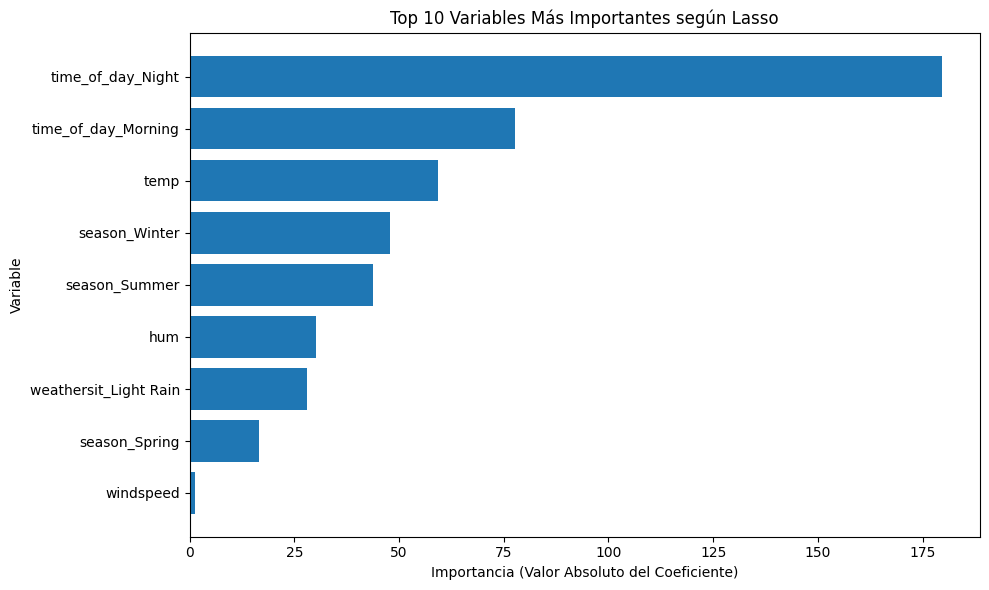

In [ ]:
# Importar la librería para visualización gráfica
import matplotlib.pyplot as plt

# Dimensiones
plt.figure(figsize=(10, 6))

top_10 = vars_importantes.head(10)

# Crear gráfico de barras horizontales
# Se utiliza el valor absoluto del coeficiente como medida de importancia
plt.barh(top_10['Variable'], top_10['Coeficiente_Abs'])
plt.xlabel('Importancia (Valor Absoluto del Coeficiente)')
plt.ylabel('Variable')
plt.title('Top 10 Variables Más Importantes según Lasso')

# Invertir el eje Y para que la variable más importante aparezca en la parte superior
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Con base en los resultados finales del modelo Lasso, se observa que windspeed presenta un coeficiente muy cercano a cero (1.20 en términos absolutos), siendo además la variable menos importante dentro de las seleccionadas. Esto confirma lo anticipado en el análisis exploratorio inicial, donde se identificó que windspeed tenía una correlación muy baja con la variable objetivo cnt (0.093). Aunque Lasso no la eliminó completamente (coeficiente ≠ 0), su impacto es prácticamente marginal en comparación con variables como time_of_day o temp. Por tanto, puede concluirse que windspeed no aporta de manera significativa al poder predictivo del modelo y que su exclusión probablemente no afectaría sustancialmente el desempeño, validando así la hipótesis planteada al inicio del análisis.

##  Análisis de resultados

#### **Pregunta 1: ¿Cuál es el grado de la transformación polinomial que fue seleccionado utilizando la técnica de validación?**


##### El grado seleccionado mediante validación cruzada fue grado 3.

Este resultado se obtuvo evaluando modelos con grado 2 y grado 3 utilizando GridSearchCV con validación cruzada de 5 folds. El modelo con transformación polinomial de grado 3 obtuvo un RMSE promedio en validación cruzada de aproximadamente 130.22, mientras que el modelo de grado 2 obtuvo un RMSE de aproximadamente 132.29.

La reducción cercana a 2 puntos en el RMSE sugiere una mejora en la capacidad predictiva del modelo de grado 3 dentro del conjunto evaluado. Esto indica que los términos cúbicos permiten capturar relaciones no lineales adicionales presentes en los datos que no son completamente representadas por el modelo de grado 2.

No obstante, la diferencia es moderada, por lo que puede interpretarse como una mejora incremental más que una superioridad drástica.

#### Pregunta 2: ¿Cuál fue el valor de α que fue seleccionado utilizando la técnica de validación para la regresión Lasso?

##### El valor del parámetro de regularización α seleccionado para la regresión Lasso fue α = 1.
Este valor se determinó mediante validación cruzada, probando los valores α{1, 2, 3, 4, 5}. Un α = 1 indica un nivel de regularización moderado que:

Balancea entre el ajuste a los datos y la simplicidad del modelo
Elimina algunas variables con coeficientes cercanos a cero (selección automática de características)
Mantiene las variables más relevantes para la predicción

Valores mayores de α habrían resultado en mayor penalización y más variables eliminadas, mientras que valores menores habrían sido menos restrictivos. El α = 1 fue el que minimizó el RMSE en validación cruzada.

#### Pregunta 3: A partir de la tabla comparativa, ¿Cuál modelo ofrece el mejor rendimiento sobre el conjunto test? ¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?

##### Según la evaluación sobre el conjunto de prueba, el modelo de Regresión Polinomial presenta el mejor desempeño, al obtener:

* Mayor valor de R² (0.4698)

* Menor RMSE (133.50)

* Menor MAE en comparación con Lasso (96.33)

Interpretación de las métricas

* R² ≈ 0.4698, lo que indica que explica aproximadamente el 47% de la variabilidad en el número de alquileres. Este valor sugiere que el modelo tiene una capacidad explicativa moderada, pero aún existe una proporción importante de variabilidad que no está siendo capturada. El modelo Lasso obtuvo un R² menor (0.4159), lo que indica menor capacidad explicativa en comparación

* RMSE ≈ 133.5015 significa que, en promedio, las predicciones se desvían aproximadamente ±133 alquileres del valor real. Considerando que la variable cnt puede oscilar aproximadamente entre 0 y 1000, este error representa alrededor del 13–15% del rango total, lo cual es razonable en términos prácticos.

* El MAE también es menor en el modelo polinomial (96.33 vs 103.72), lo que confirma que, en promedio, los errores absolutos son menores en este modelo.

El mejor desempeño del modelo polinomial puede atribuirse a su capacidad para capturar relaciones no lineales complejas mediante términos de grado 3. En contraste, el modelo Lasso trabaja sobre una estructura lineal regularizada, lo que limita su capacidad para modelar interacciones no lineales de mayor orden.

En este conjunto de datos, el modelo polinomial ofrece mejor capacidad predictiva; sin embargo, Lasso aporta mayor simplicidad e interpretabilidad.

#### Pregunta 4: ¿Cuáles variables fueron seleccionadas con el modelo Lasso? A partir de estas, ¿Qué interpretación de cara al problema puedes dar? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.

##### Variables seleccionadas por Lasso (coeficiente ≠ 0):
Según el análisis, Lasso conservó 9 de las 11 variables, eliminando 2 que consideró irrelevantes. Las variables más importantes fueron:
Top 5 variables por orden de importancia:


1.   time_of_day_Night (coef: -179.71): La noche reduce drásticamente los
alquileres

2. time_of_day_Morning (coef: -77.61): La mañana también reduce alquileres vs. tarde

3. temp (coef: 59.22): A mayor temperatura, más alquileres

4. season_Winter (coef: -47.77): El invierno reduce significativamente los alquileres

5. season_Summer (coef: -43.77): Incluso el verano reduce alquileres vs. la estación de referencia

Interpretación y aplicación práctica:

Momento del día es crítico:

* Las noches tienen menos 180 alquileres menos que las tardes
* Acción: Reducir inventario disponible durante la noche para optimizar recursos


Temperatura es un predictor fuerte:

* Coeficiente positivo de 59.22 indica fuerte correlación con demanda
* Acción: Aumentar disponibilidad en días cálidos, promociones en días fríos


Estacionalidad importa:

* El invierno muestra la mayor caída (~48 alquileres menos)
* Acción: Planificar mantenimiento de bicicletas en invierno, ajustar precios estacionalmente


Variables eliminadas:

* Lasso eliminó 2 variables (probablemente relacionadas con humedad o clima específico con bajo impacto)
* Beneficio: Simplifica el modelo sin perder capacidad predictiva



Decisiones estratégicas basadas en este conocimiento:

* Gestión de inventario: Redistribuir bicicletas según hora del día y temporada
* Pricing dinámico: Precios más altos en momentos de alta demanda (tardes cálidas), descuentos en invierno/noches
* Mantenimiento: Programar durante períodos de baja demanda (invierno, noches)
* Marketing: Campañas focalizadas en variables controlables (promocionar uso matutino, servicios nocturnos especiales)

Este modelo permite decisiones basadas en datos concretos en lugar de intuición, optimizando la operación del sistema de alquiler de bicicletas.

## Crear .html

In [ ]:
!jupyter nbconvert --to html "ProjectEtapa1.ipynb"

[NbConvertApp] Converting notebook ProjectEtapa1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 598795 bytes to ProjectEtapa1.html
